In [1]:
import pysimdamicm
import pysimdamicm.scripts
print("pysimdamicm:", pysimdamicm.__file__)
print("scripts:", pysimdamicm.scripts.__file__)

pysimdamicm: None
scripts: None


## Imports

In [1]:
import pysimdamicm

import ROOT

import pandas as pd
import numpy as np
from astropy.io import fits
import matplotlib
import matplotlib.pyplot as plt

In [2]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from skimage.measure import label, regionprops

In [3]:
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.default"] = "regular"

### Helpers

In [4]:
def make_samples(masked_img):
    """
    Build N x 3 samples from a thresholded CCD image (in keV).
    Uses raw E (no log) as the third feature.

    Returns:
      X_raw : (N,3) with columns [y, x, E]
      idx_yx: (N,2) integer pixel coords [y, x]
    """
    valid = np.isfinite(masked_img) & (masked_img > 0)
    ys, xs = np.nonzero(valid)
    E = masked_img[ys, xs].astype(np.float64)

    X_raw = np.column_stack([ys, xs, E])
    idx_yx = np.column_stack([ys, xs])
    return X_raw, idx_yx

Fit GMM

In [5]:
REG_COVAR = 1e-6
RANDOM_STATE = 209

def _unscale_covariances(gmm, scaler):
    """
    Map covariances from standardized space back to original feature space.
    Handles only covariance_type='full' (what you're using).
    """
    if gmm.covariance_type != "full":
        raise ValueError("This helper currently assumes covariance_type='full'.")

    D = np.diag(scaler.scale_)
    covs_std = gmm.covariances_                 # shape: (K, d, d)
    covs_raw = np.empty_like(covs_std)
    for k in range(covs_std.shape[0]):
        covs_raw[k] = D @ covs_std[k] @ D       # Σ_raw = D Σ_std D
    return covs_raw

def fit_gmms_over_K(X_raw, K_RANGE, reg_covar=REG_COVAR, random_state=RANDOM_STATE):
    """
    Standardize features, fit a full-covariance GMM for each K.
    Returns: list of dicts with model, labels, BIC, AIC, scaler, and
             means/covariances mapped back to ORIGINAL units.
    """
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X_raw)

    results = []
    for K in K_RANGE:
        gmm = GaussianMixture(
            n_components=K,
            covariance_type="full",
            reg_covar=reg_covar,
            random_state=random_state
        )
        gmm.fit(X_std)

        # Predict labels in standardized space, but keep for reference
        labels = gmm.predict(X_std)

        # --- NEW: parameters in original (unscaled) space ---
        means_raw = scaler.inverse_transform(gmm.means_)       # shape: (K, d)
        covs_raw  = _unscale_covariances(gmm, scaler)          # shape: (K, d, d)

        bic = gmm.bic(X_std)
        aic = gmm.aic(X_std)
        results.append({
            "K": K,
            "model": gmm,
            "labels": labels,         # labels on the standardized X
            "bic": bic,
            "aic": aic,
            "scaler": scaler,
            "means_raw": means_raw,   # <-- in original units
            "covs_raw": covs_raw      # <-- in original units
        })

    results.sort(key=lambda r: r["bic"])
    return results

Plotting options

In [18]:
from matplotlib.colors import ListedColormap

def plot_fullframe_clusters(idx_yx, labels, frame_size=(320, 640), title=None):
    H, W = frame_size
    y = idx_yx[:, 0]
    x = idx_yx[:, 1]

    # ---- Build image storing cluster labels ----
    img = np.full((H, W), -1, dtype=int)
    img[y, x] = labels

    # ---- Define colors ----
    dark_pink  = [0.80, 0.10, 0.45, 1.0]   # strong pink/magenta
    light_blue = [0.45, 0.75, 0.95, 1.0]   # clear light blue

    colors = np.vstack([
        [1, 1, 1, 1],     # background = white
        light_blue,       # cluster 0
        dark_pink         # cluster 1
    ])

    cmap = ListedColormap(colors)

    img_plot = img + 1  # shift background (-1) → 0

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(24, 4))
    ax.imshow(img_plot, origin='lower', cmap=cmap, interpolation='none')

    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel("Column index (x)")
    ax.set_ylabel("Row index (y)")
    ax.set_title(title if title else "GMM clusters (full frame)")

    plt.tight_layout()
    plt.show()



In [20]:
from matplotlib.colors import ListedColormap

def plot_one_cluster(idx_yx, result, ccd_shape, cluster_id, origin="lower"):
    """
    imshow-style plot (like your example) but only for a single cluster_id.
    """
    H, W = ccd_shape
    labels = np.asarray(result["labels"])

    # pick points for this cluster
    sel = (labels == cluster_id)
    ys = np.asarray(idx_yx[:, 0], dtype=int)[sel]
    xs = np.asarray(idx_yx[:, 1], dtype=int)[sel]

    # make a 0/1 image for this cluster only
    img = np.zeros((H, W), dtype=np.uint8)
    img[ys, xs] = 1

    # colormap: background white, cluster blue (change if you want)
    cmap = ListedColormap(["white", "#1f77b4"])

    plt.figure(figsize=(24, 4))
    plt.imshow(img, origin=origin, cmap=cmap, interpolation="nearest", vmin=0, vmax=1)
    plt.title(f"GMM Cluster {cluster_id}")
    plt.xlabel("Column index (x)")
    plt.ylabel("Row index (y)")
    plt.tight_layout()
    plt.show()


In [38]:
def plot_cluster_gallery_on_frame(idx_yx, result, ccd_shape, max_points_per_cluster=None,
                                   panel_width=20):
    """
    Plot the cluster gallery for a single (best) result.
    Each panel shows the FULL CCD frame, with only that cluster overplotted.
    Panels are stacked vertically.

    Parameters
    ----------
    idx_yx : (N, 2) array of [y, x] pixel coordinates
    result : dict with keys "K" and "labels"
    ccd_shape : (H, W) shape of the CCD
    max_points_per_cluster : optional cap on points per cluster
    panel_width : width in inches of each panel (height is set by CCD aspect ratio)
    """
    y_all, x_all = idx_yx[:, 0], idx_yx[:, 1]
    H, W = ccd_shape

    K = result["K"]
    labels = result["labels"]

    panel_height = panel_width * H / W  # match CCD aspect ratio

    fig, axes = plt.subplots(
        K, 1,
        figsize=(panel_width, panel_height * K),
        squeeze=False
    )
    fig.suptitle(f"GMM clusters (K={K}) — full-frame view", y=1.0)

    rng = np.random.default_rng(209)

    for k in range(K):
        ax = axes[k][0]
        sel = (labels == k)

        if max_points_per_cluster is not None and sel.sum() > max_points_per_cluster:
            idx = np.flatnonzero(sel)
            idx = rng.choice(idx, size=max_points_per_cluster, replace=False)
            sel = np.zeros_like(labels, dtype=bool)
            sel[idx] = True

        ax.scatter(x_all[sel], y_all[sel], s=2)

        ax.set_xlim(0, W)
        ax.set_ylim(0, H)
        ax.set_aspect("equal", "box")

        ax.set_title(f"Cluster {k}")
        ax.set_xlabel("x (col)")
        ax.set_ylabel("y (row)")

    plt.tight_layout()
    plt.show()

In [33]:
def plot_clusters_on_frame(idx_yx, result, ccd_shape, clusters_to_show=None,
                            max_points_per_cluster=None, cmap_name="tab10",
                            figsize=(8, 8), point_size=2):
    """
    Plot selected clusters on a single full CCD frame, each in a different color.

    Parameters
    ----------
    idx_yx : (N, 2) array of [y, x] pixel coordinates
    result : dict with keys "K" and "labels"
    ccd_shape : (H, W) shape of the CCD
    clusters_to_show : iterable of cluster indices to plot (e.g. [0, 1, 2, 3]).
        If None, all clusters are shown.
    max_points_per_cluster : optional cap on points per cluster
    cmap_name : matplotlib colormap name (qualitative recommended)
    """
    y_all, x_all = idx_yx[:, 0], idx_yx[:, 1]
    H, W = ccd_shape

    K = result["K"]
    labels = result["labels"]

    if clusters_to_show is None:
        clusters_to_show = list(range(K))
    else:
        clusters_to_show = list(clusters_to_show)
        bad = [k for k in clusters_to_show if k < 0 or k >= K]
        if bad:
            raise ValueError(f"Invalid cluster indices {bad}; valid range is 0..{K-1}")

    cmap = plt.get_cmap(cmap_name)
    rng = np.random.default_rng(209)

    fig, ax = plt.subplots(figsize=figsize)

    for i, k in enumerate(clusters_to_show):
        sel = (labels == k)
        if not sel.any():
            continue

        if max_points_per_cluster is not None and sel.sum() > max_points_per_cluster:
            idx = np.flatnonzero(sel)
            idx = rng.choice(idx, size=max_points_per_cluster, replace=False)
            sel = np.zeros_like(labels, dtype=bool)
            sel[idx] = True

        color = cmap(i % cmap.N)
        ax.scatter(x_all[sel], y_all[sel], s=point_size,
                   color=color, label=f"Cluster {k}")

    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_aspect("equal", "box")
    ax.set_xlabel("x (col)")
    ax.set_ylabel("y (row)")
    ax.set_title(f"GMM clusters (showing {len(clusters_to_show)} of K={K})")

    leg = ax.legend(markerscale=4, loc="upper left", bbox_to_anchor=(1.01, 1), framealpha=0.9)
    for handle in leg.legend_handles:
        handle.set_sizes([30])

    plt.tight_layout()
    plt.show()

In [84]:
def plot_clusters_on_frame(idx_yx, result, ccd_shape, clusters_to_show=None,
                            max_points_per_cluster=None, cmap_name="tab10",
                            figsize=(8, 8), point_size=2,
                            xlim=None, ylim=None):
    """
    Plot selected clusters on a single full CCD frame, each in a different color.

    Parameters
    ----------
    idx_yx : (N, 2) array of [y, x] pixel coordinates
    result : dict with keys "K" and "labels"
    ccd_shape : (H, W) shape of the CCD
    clusters_to_show : iterable of cluster indices to plot (e.g. [0, 1, 2, 3]).
        If None, all clusters are shown.
    max_points_per_cluster : optional cap on points per cluster
    cmap_name : matplotlib colormap name (qualitative recommended)
    xlim : (xmin, xmax) tuple to zoom into a column range. If None, full width.
    ylim : (ymin, ymax) tuple to zoom into a row range. If None, full height.
    """
    y_all, x_all = idx_yx[:, 0], idx_yx[:, 1]
    H, W = ccd_shape

    K = result["K"]
    labels = result["labels"]

    if clusters_to_show is None:
        clusters_to_show = list(range(K))
    else:
        clusters_to_show = list(clusters_to_show)
        bad = [k for k in clusters_to_show if k < 0 or k >= K]
        if bad:
            raise ValueError(f"Invalid cluster indices {bad}; valid range is 0..{K-1}")

    cmap = plt.get_cmap(cmap_name)
    rng = np.random.default_rng(209)

    fig, ax = plt.subplots(figsize=figsize)

    for i, k in enumerate(clusters_to_show):
        sel = (labels == k)
        if not sel.any():
            continue

        if max_points_per_cluster is not None and sel.sum() > max_points_per_cluster:
            idx = np.flatnonzero(sel)
            idx = rng.choice(idx, size=max_points_per_cluster, replace=False)
            sel = np.zeros_like(labels, dtype=bool)
            sel[idx] = True

        color = cmap(i % cmap.N)
        ax.scatter(x_all[sel], y_all[sel], s=point_size,
                   color=color, label=f"Cluster {k}")

    ax.set_xlim(xlim if xlim is not None else (0, W))
    ax.set_ylim(ylim if ylim is not None else (0, H))
    ax.set_aspect("equal", "box")
    ax.set_xlabel("x (col)")
    ax.set_ylabel("y (row)")
    title = f"GMM clusters (showing {len(clusters_to_show)} of K={K})"
    if xlim is not None or ylim is not None:
        title += f"  [zoom: x={xlim}, y={ylim}]"
    ax.set_title(title)

    leg = ax.legend(markerscale=4, loc="upper left", bbox_to_anchor=(1.01, 1), framealpha=0.9)
    for handle in leg.legend_handles:
        handle.set_sizes([30])

    plt.tight_layout()
    plt.show()

### Pull waders calibrated image

In [8]:
fits_path = "/home/dsalma/damicm-ml/high_energy_img/avg_Image_8_Low_Temp_109_20260505_135919_27_EXT1_waders.fits"

with fits.open(fits_path) as hdul:
    hdul.info()

Filename: /home/dsalma/damicm-ml/high_energy_img/avg_Image_8_Low_Temp_109_20260505_135919_27_EXT1_waders.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  CALIBRATED    1 PrimaryHDU     158   (3500, 500)   float64   
  1  FULLMASK      1 ImageHDU         8   (3500, 500)   float64   
  2  CLSMASK       1 ImageHDU         8   (3500, 500)   float64   


In [9]:
with fits.open(fits_path) as hdul:
    cal_img = hdul[0].data

In [10]:
print("shape:", cal_img.shape)
print("type:", type(cal_img))
print("dtype:", cal_img.dtype)

shape: (500, 3500)
type: <class 'numpy.ndarray'>
dtype: >f8


In [11]:
# convert image from calibration into electron into keV
cal_img = (cal_img * 3.74)/1000  # e- to keV

### GMM analysis

In [74]:
K_RANGE = [4]

In [75]:
# build samples
X_raw_cut, idx_yx = make_samples(cal_img)

In [76]:
results_cut = fit_gmms_over_K(X_raw_cut, K_RANGE, reg_covar=REG_COVAR, random_state=RANDOM_STATE)

In [79]:
best = results_cut[0]

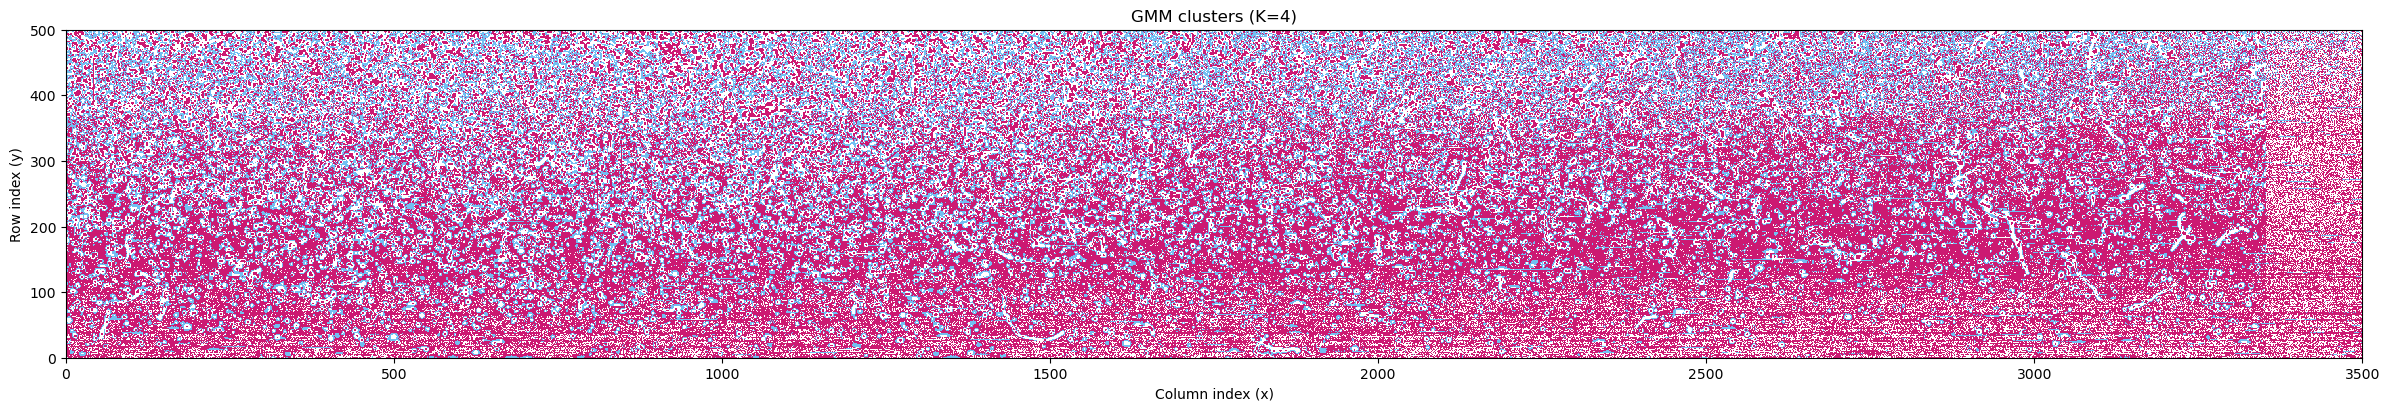

In [80]:
plot_fullframe_clusters(
    idx_yx,
    best["labels"],
    frame_size=cal_img.shape,
    title=f"GMM clusters (K={best['K']})"
)

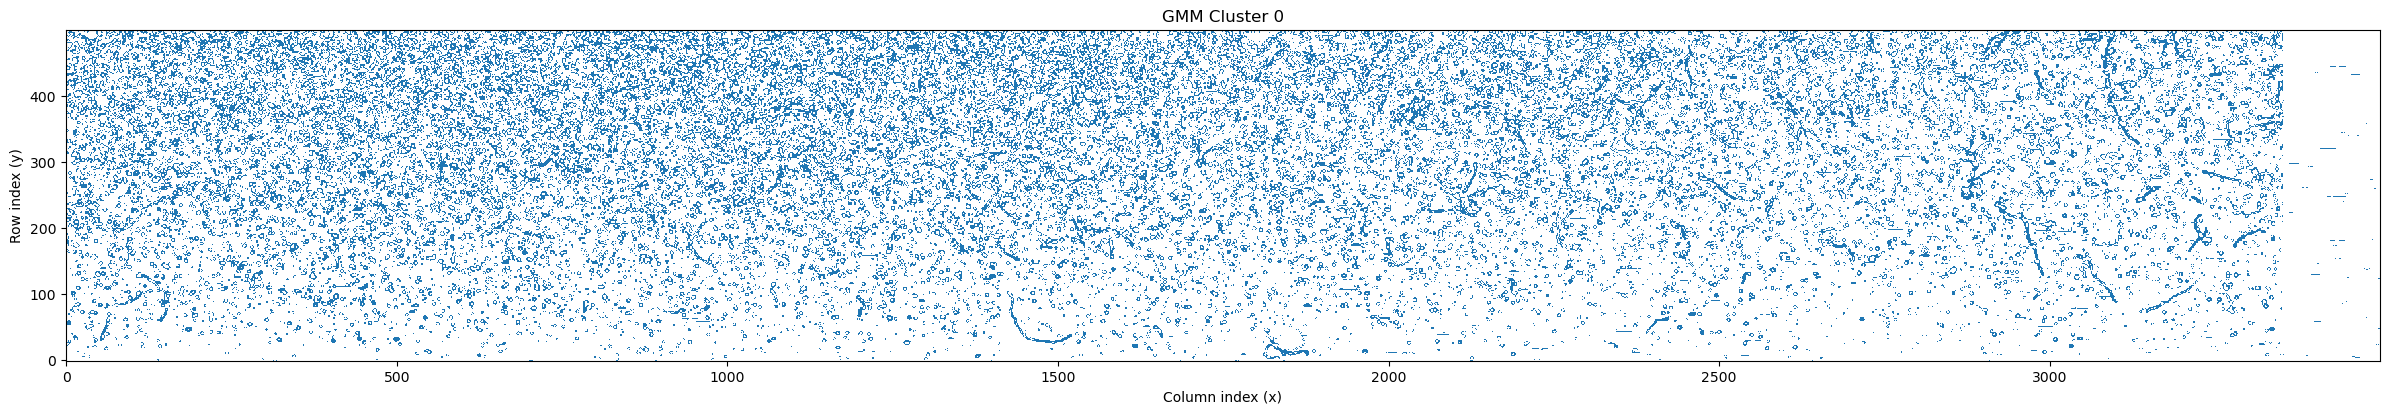

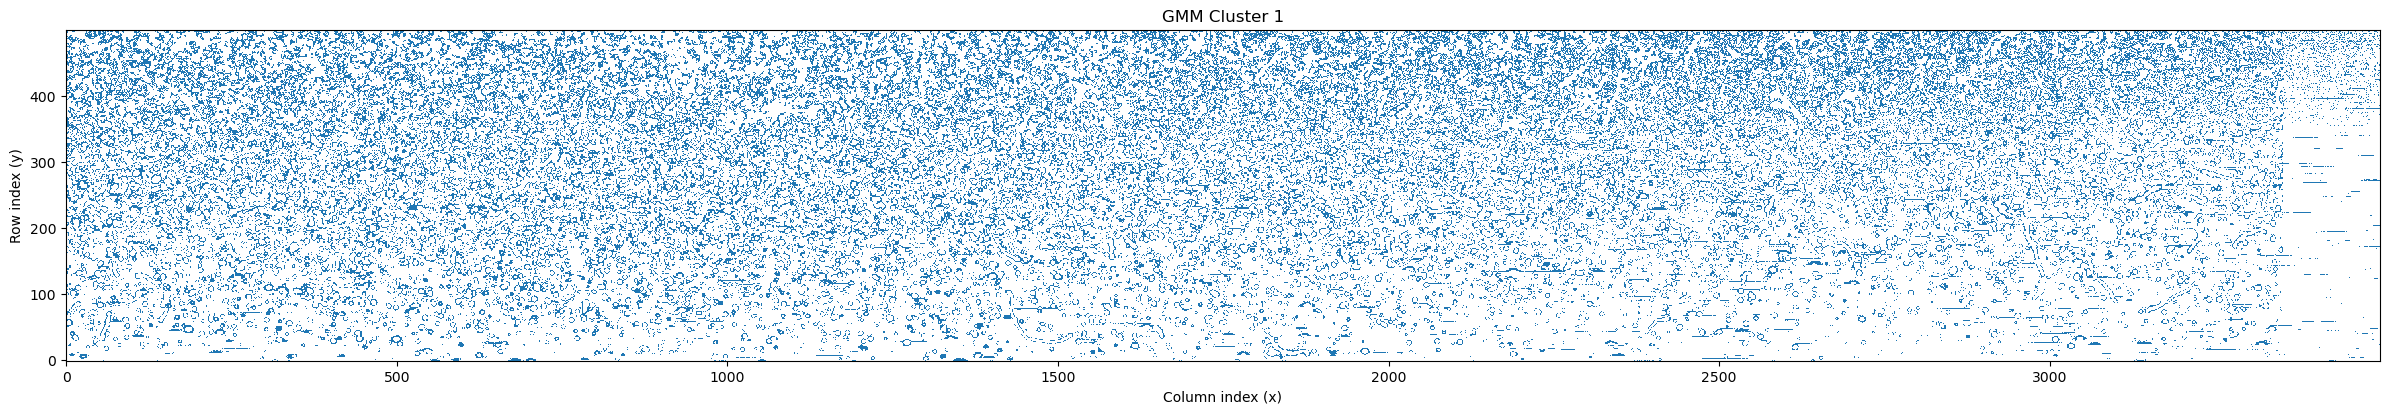

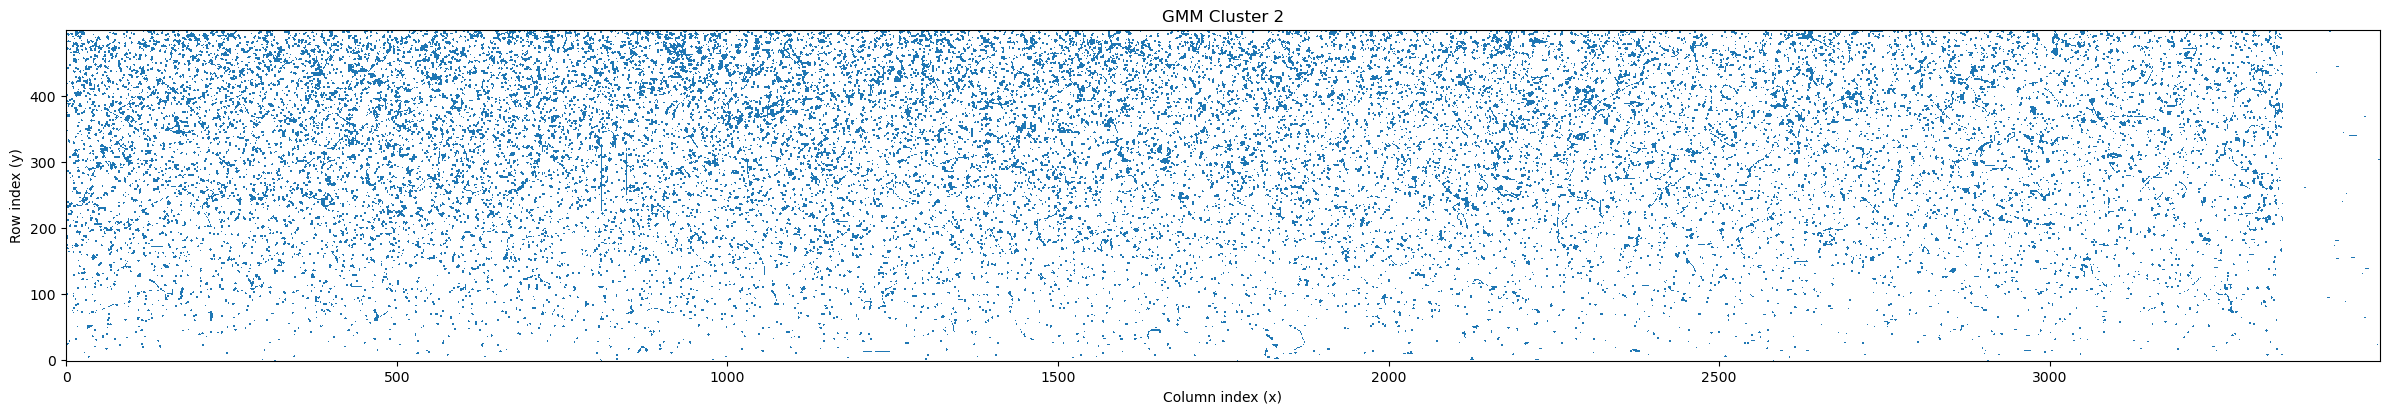

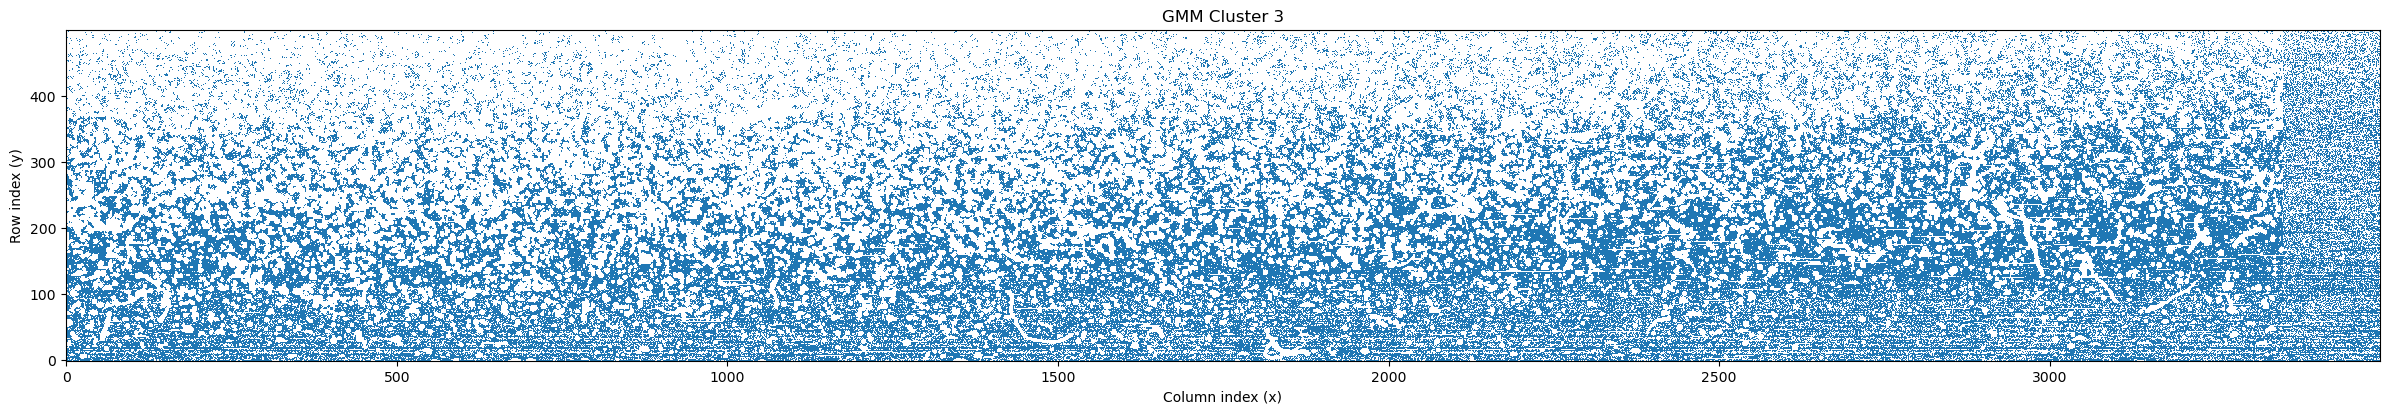

In [82]:
plot_one_cluster(idx_yx, best, ccd_shape=cal_img.shape, cluster_id=0)
plot_one_cluster(idx_yx, best, ccd_shape=cal_img.shape, cluster_id=1)
plot_one_cluster(idx_yx, best, ccd_shape=cal_img.shape, cluster_id=2)
plot_one_cluster(idx_yx, best, ccd_shape=cal_img.shape, cluster_id=3)


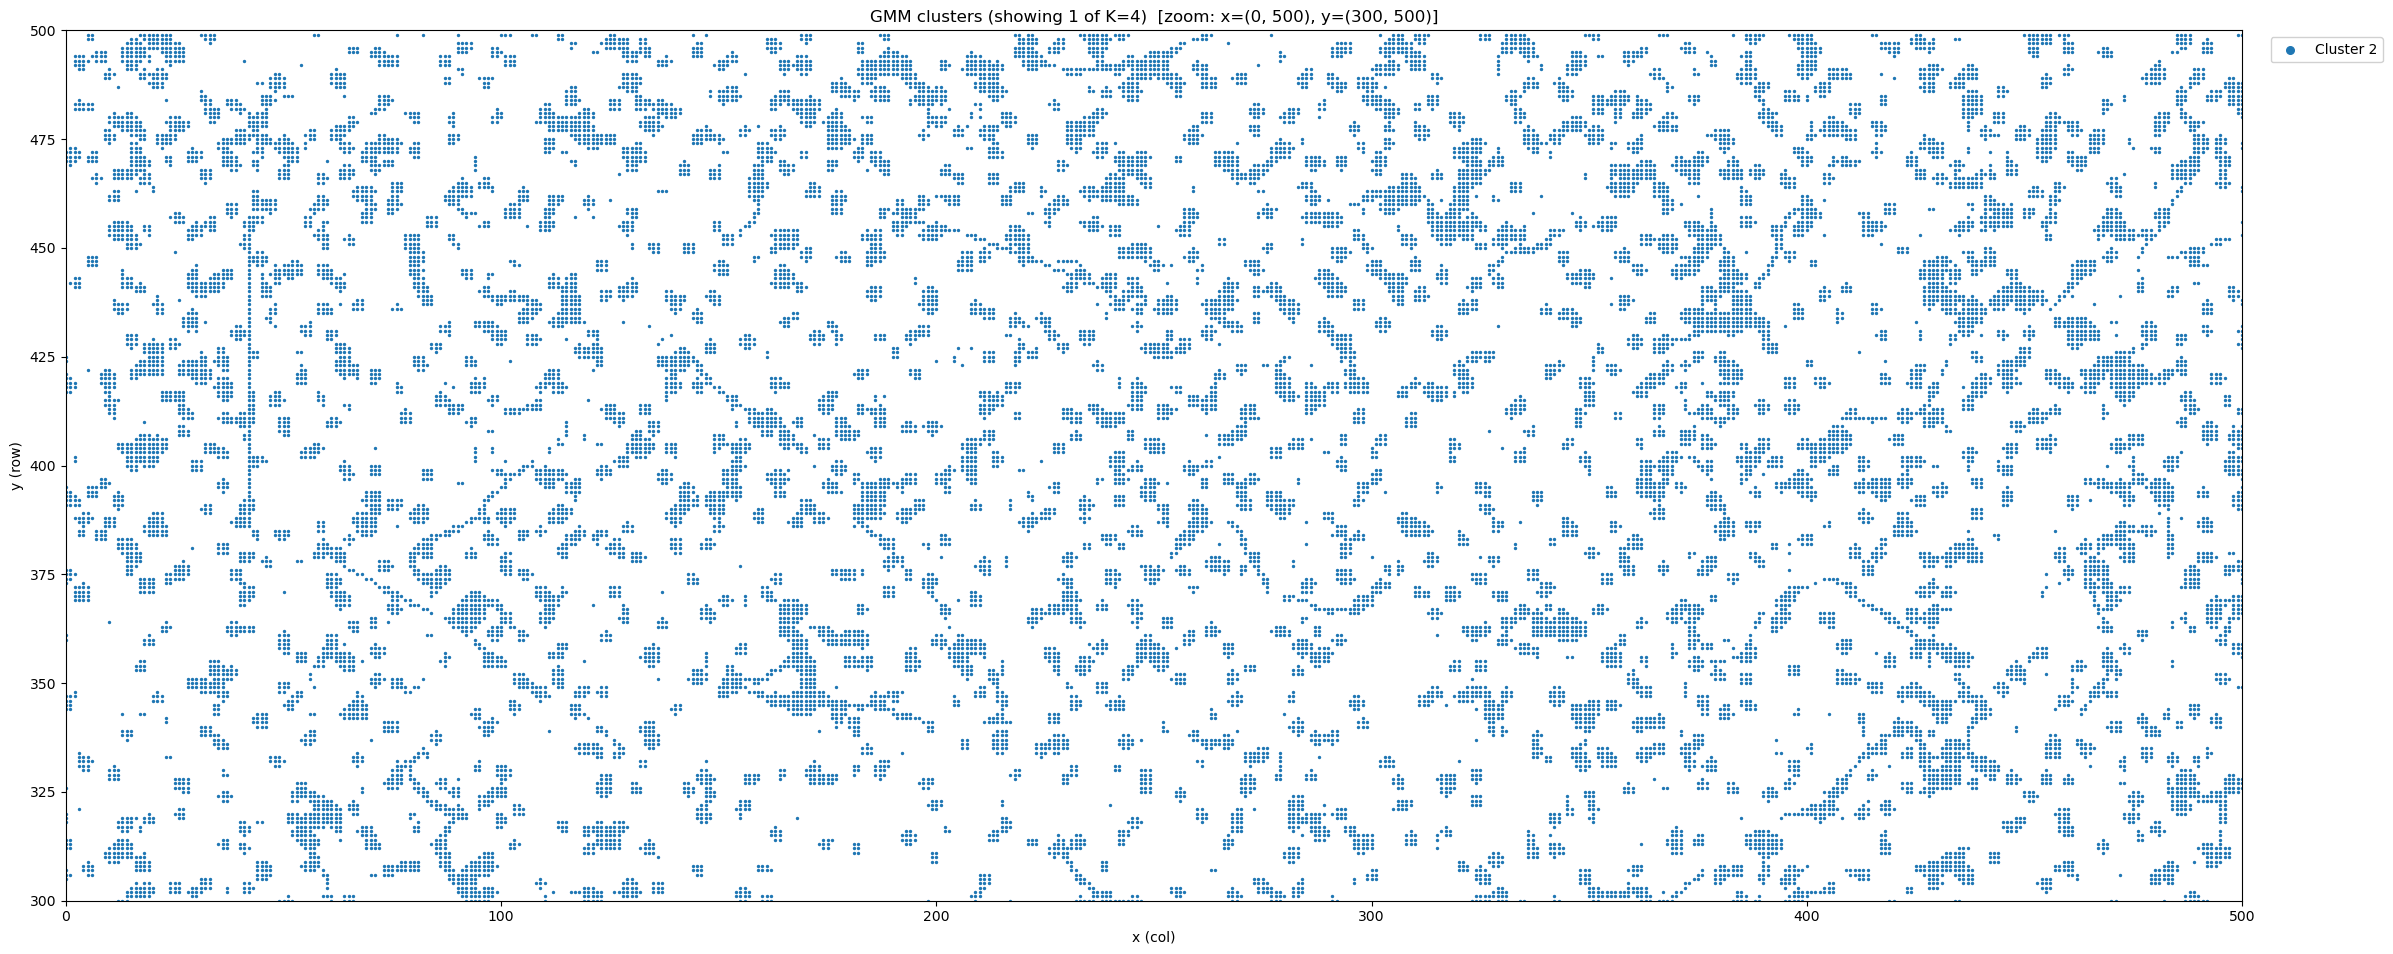

In [102]:
# zoom into a specific region
plot_clusters_on_frame(idx_yx, best, ccd_shape=cal_img.shape, clusters_to_show=[2],
                        xlim=(0, 500), ylim=(300, 500), figsize=(24, 10))

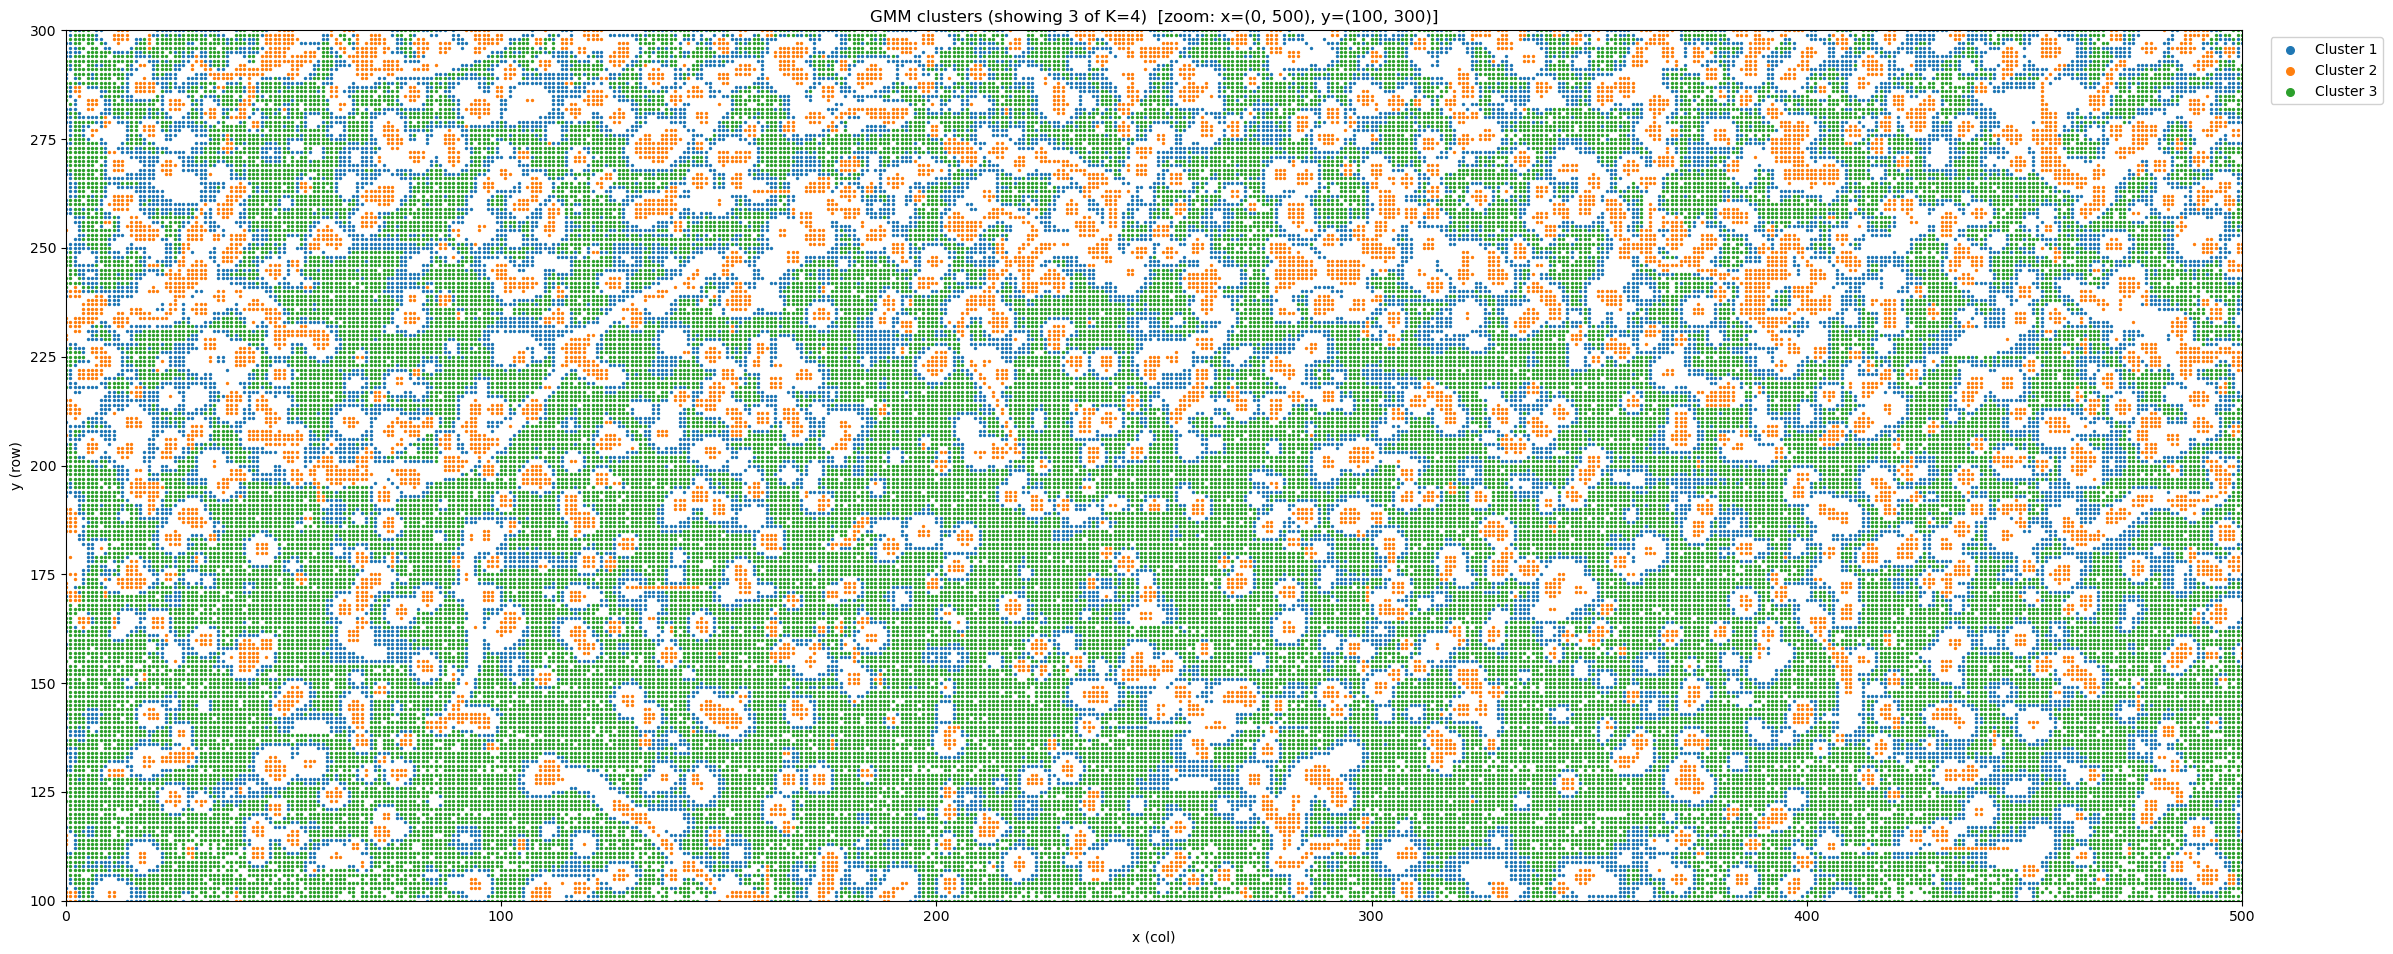

In [100]:
# zoom into a specific region
plot_clusters_on_frame(idx_yx, best, ccd_shape=cal_img.shape, clusters_to_show=[1, 2, 3],
                        xlim=(0, 500), ylim=(100, 300), figsize=(24, 10))

In [ ]:
plot_one_cluster(idx_yx, best, ccd_shape=cal_img.shape, cluster_id=1)

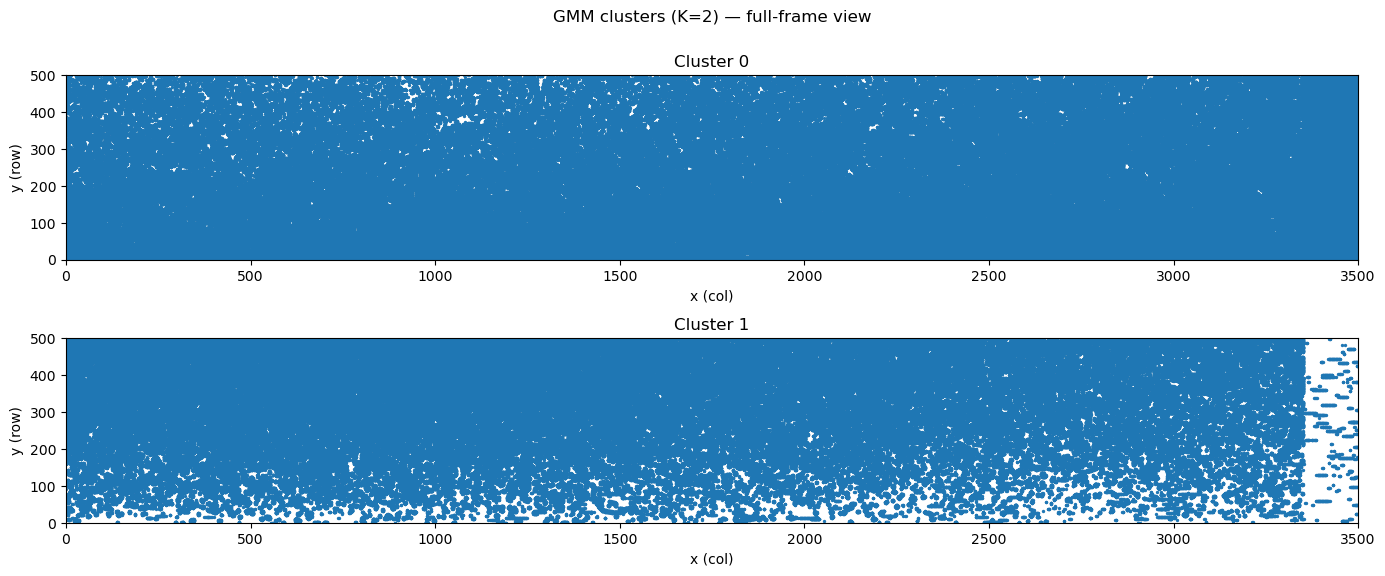

In [54]:
plot_cluster_gallery_on_frame(idx_yx, best, ccd_shape=cal_img.shape)

In [92]:
import numpy as np
from scipy.ndimage import label as cc_label

def blobs_from_gmm(X_raw, gmm_labels, frame_size, cluster_id):
    """
    X_raw      : (N,3) array [y, x, E]
    gmm_labels : (N,) GMM labels (same order as X_raw)
    frame_size : (H, W)
    cluster_id : int or iterable of ints — GMM component(s) to extract

    Returns:
      blobs   : dict {blob_id: array [[y,x,E], ...]}
      labeled : (H,W) blob-ID image
    """
    H, W = frame_size

    cluster_ids = np.atleast_1d(cluster_id)
    sel = np.isin(gmm_labels, cluster_ids)
    if not np.any(sel):
        labeled = np.zeros((H, W), dtype=int)
        return {}, labeled

    y = X_raw[sel, 0].astype(int)
    x = X_raw[sel, 1].astype(int)
    E = X_raw[sel, 2].astype(float)

    img = np.zeros((H, W), dtype=np.uint8)
    img[y, x] = 1

    # HARD-CODED 8-connectivity
    labeled = cc_label(img, structure=np.ones((3, 3), dtype=int))[0]

    blob_ids = labeled[y, x]
    blobs = {}

    for bid in np.unique(blob_ids):
        if bid == 0:
            continue
        m = (blob_ids == bid)
        blobs[bid] = np.column_stack([y[m], x[m], E[m]])

    return blobs, labeled


In [97]:
blobs, labeled = blobs_from_gmm(
    X_raw=X_raw_cut,
    gmm_labels=best["labels"],
    frame_size=cal_img.shape,
    cluster_id=2
)

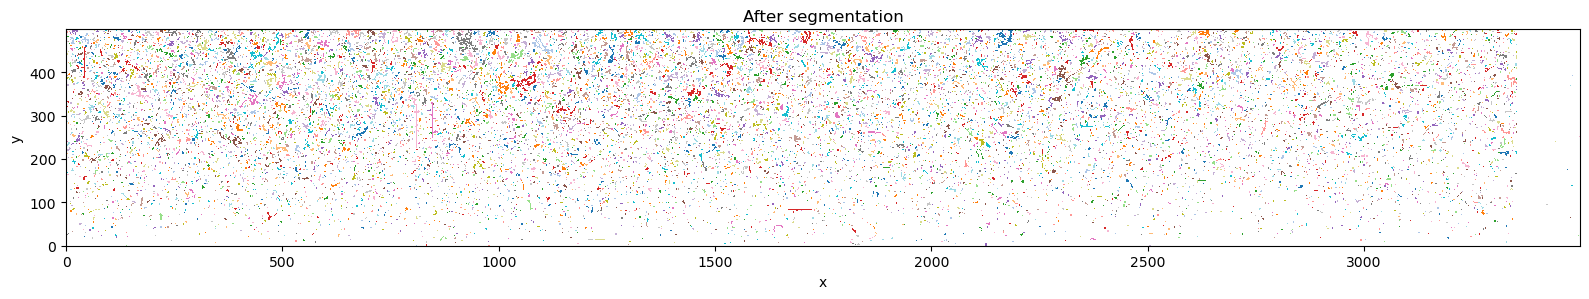

In [98]:
# build a colormap: 0 = white (background), blobs = colors
n_blobs = len(blobs)

colors = [(1, 1, 1, 1)]  # background = white
base = plt.cm.tab20.colors

for i in range(n_blobs):
    colors.append(base[i % len(base)])

cmap = ListedColormap(colors)

plt.figure(figsize=(16, 10))
plt.imshow(labeled, origin="lower", cmap=cmap, interpolation="none")
plt.title("After segmentation")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


In [103]:
# how many blobs
print("Number of blobs:", len(blobs))

# pick a blob ID (e.g. first one)
bid = list(blobs.keys())[0]

blob = blobs[bid]
print(f"Blob {bid} has {len(blob)} pixels")
print("First 10 pixels [y, x, E]:")
print(blob[:10])

Number of blobs: 15431
Blob 1 has 2 pixels
First 10 pixels [y, x, E]:
[[  0.         315.           3.05069431]
 [  0.         316.           3.23753386]]


In [104]:
df_blobs = pd.DataFrame(
    {
        "blob_id": list(blobs.keys()),
        "points": list(blobs.values())
    }
)

In [105]:
df_blobs.head()

,blob_id,points
0,1,"[[0.0, 315.0, 3.050694311439007], [0.0, 316.0,..."
1,2,"[[0.0, 809.0, 3.1478423346732365], [1.0, 809.0..."
2,3,"[[0.0, 1770.0, 2.749955832206569], [0.0, 1771...."
3,4,"[[0.0, 2581.0, 7.510802667768334], [0.0, 2582...."
4,5,"[[0.0, 2905.0, 4.609493941991366], [0.0, 2906...."


In [106]:
df_blobs["cluster_size"] = df_blobs["points"].apply(len)

In [107]:
df_blobs.head()

,blob_id,points,cluster_size
0,1,"[[0.0, 315.0, 3.050694311439007], [0.0, 316.0,...",2
1,2,"[[0.0, 809.0, 3.1478423346732365], [1.0, 809.0...",3
2,3,"[[0.0, 1770.0, 2.749955832206569], [0.0, 1771....",2
3,4,"[[0.0, 2581.0, 7.510802667768334], [0.0, 2582....",2
4,5,"[[0.0, 2905.0, 4.609493941991366], [0.0, 2906....",3


In [108]:
df_blobs["energy"] = df_blobs["points"].apply(
    lambda pts: np.sum(np.asarray(pts)[:, 2])
)

In [109]:
df_blobs.head()

,blob_id,points,cluster_size,energy
0,1,"[[0.0, 315.0, 3.050694311439007], [0.0, 316.0,...",2,6.288228
1,2,"[[0.0, 809.0, 3.1478423346732365], [1.0, 809.0...",3,14.633012
2,3,"[[0.0, 1770.0, 2.749955832206569], [0.0, 1771....",2,5.588104
3,4,"[[0.0, 2581.0, 7.510802667768334], [0.0, 2582....",2,14.007457
4,5,"[[0.0, 2905.0, 4.609493941991366], [0.0, 2906....",3,38.048109


In [110]:
min_E = min(p[2] for pts in df_blobs["points"] for p in pts)
print(min_E)

2.1769042148183826


In [36]:

def weighted_std_xy(points):
    """
    points: array of shape (N,3) with columns [y, x, E]
    Returns: wSTD_y, wSTD_x
    """
    y = points[:, 0]
    x = points[:, 1]
    E = points[:, 2]

    Etot = E.sum()
    if Etot == 0:
        return np.nan, np.nan

    y_bar = np.sum(E * y) / Etot
    x_bar = np.sum(E * x) / Etot

    wSTD_y = np.sqrt(np.sum(E * (y - y_bar)**2) / Etot)
    wSTD_x = np.sqrt(np.sum(E * (x - x_bar)**2) / Etot)

    return wSTD_y, wSTD_x

In [37]:
df_blobs[["wSTD_y", "wSTD_x"]] = (
    df_blobs["points"]
    .apply(lambda pts: pd.Series(weighted_std_xy(pts)))
)

In [38]:
df_blobs.head()

,blob_id,points,cluster_size,energy,wSTD_y,wSTD_x
0,1,"[[0.0, 272.0, 0.037287047078601095], [0.0, 273...",54,5.037471,1.184391,2.197259
1,2,"[[0.0, 325.0, 0.10781292067582199], [0.0, 326....",39,248.395053,2.409261,0.948588
2,3,"[[0.0, 380.0, 0.015077902006953813], [0.0, 381...",2,0.037288,0.000000,0.490768
3,4,"[[0.0, 383.0, 0.014797598166209645]]",1,0.014798,0.000000,0.000000
4,5,"[[0.0, 513.0, 0.029731704362683922], [0.0, 514...",159,65.735329,3.269959,2.043559


In [39]:
df_blobs["wSTD_xy"] = np.sqrt(
    0.5 * (df_blobs["wSTD_x"]**2 + df_blobs["wSTD_y"]**2)
)

In [40]:
df_blobs.head()

,blob_id,points,cluster_size,energy,wSTD_y,wSTD_x,wSTD_xy
0,1,"[[0.0, 272.0, 0.037287047078601095], [0.0, 273...",54,5.037471,1.184391,2.197259,1.765040
1,2,"[[0.0, 325.0, 0.10781292067582199], [0.0, 326....",39,248.395053,2.409261,0.948588,1.830896
2,3,"[[0.0, 380.0, 0.015077902006953813], [0.0, 381...",2,0.037288,0.000000,0.490768,0.347025
3,4,"[[0.0, 383.0, 0.014797598166209645]]",1,0.014798,0.000000,0.000000,0.000000
4,5,"[[0.0, 513.0, 0.029731704362683922], [0.0, 514...",159,65.735329,3.269959,2.043559,2.726606


lets make these plots!

1. Energy vs. wSTD_xy

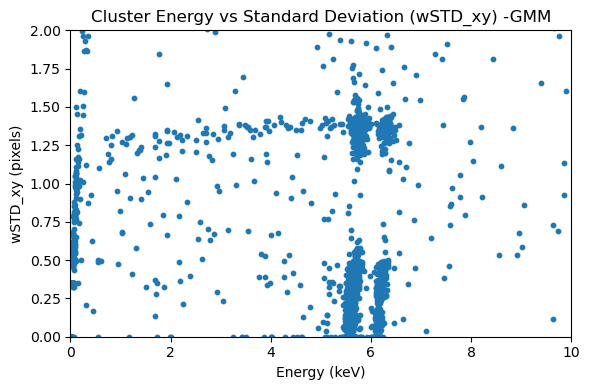

In [41]:
plt.figure(figsize=(6, 4))
plt.scatter(df_blobs["energy"], df_blobs["wSTD_xy"], s=10)
plt.xlabel("Energy (keV)")
plt.ylabel("wSTD_xy (pixels)")
plt.xlim(0,10)
plt.ylim(0,2)
plt.title("Cluster Energy vs Standard Deviation (wSTD_xy) -GMM")
plt.tight_layout()
plt.show()


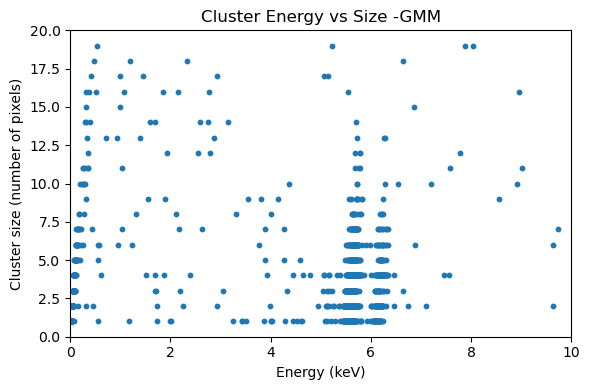

In [42]:
plt.figure(figsize=(6, 4))
plt.scatter(df_blobs["energy"], df_blobs["cluster_size"], s=10)
plt.xlabel("Energy (keV)")
plt.ylabel("Cluster size (number of pixels)")
plt.title("Cluster Energy vs Size -GMM")
plt.xlim(0,10)
plt.ylim(0,20)
plt.tight_layout()
plt.show()

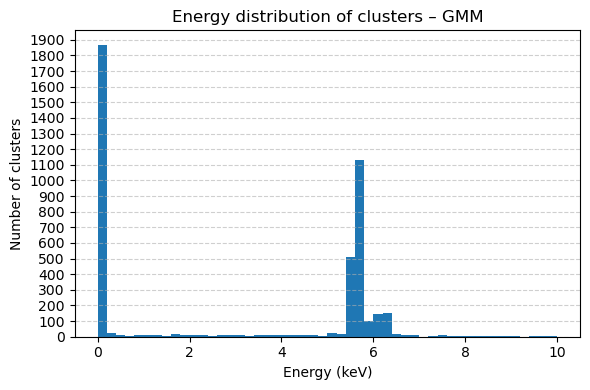

In [45]:
plt.figure(figsize=(6, 4))
plt.hist(df_blobs["energy"], bins=50, range=(0, 10))

plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters – GMM")

ax = plt.gca()
ymax = int(ax.get_ylim()[1])

# --- y-axis ticks every 10 ---
ax.set_yticks(np.arange(0, ymax + 1, 100))

# --- grid only on major ticks ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
# from scipy.stats import norm

# # --- histogram settings (match your good histogram) ---
# bins = 50
# hist_range = (2, 10)

# # --- fit range for the 2-Gaussian mixture ---
# fit_min, fit_max = 5.0, 7.0

# data = df_blobs["energy"].to_numpy(dtype=float)
# data = data[np.isfinite(data)]

# # --- data used for fitting ONLY (5–7 keV) ---
# fit_data = data[(data >= fit_min) & (data <= fit_max)]

# # --- Fit 2-Gaussian mixture to UNBINNED data ---
# gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=0)
# gmm.fit(fit_data.reshape(-1, 1))

# means = gmm.means_.ravel()
# stds = np.sqrt(gmm.covariances_.ravel())
# weights = gmm.weights_.ravel()

# # sort components by mean (nice reporting/plotting)
# order = np.argsort(means)
# means, stds, weights = means[order], stds[order], weights[order]

# # --- plot histogram (ALL data) exactly like before ---
# plt.figure(figsize=(6, 4))
# counts, bin_edges, _ = plt.hist(data, bins=bins, range=hist_range)

# plt.xlabel("Energy (keV)")
# plt.ylabel("Number of clusters")
# plt.title("Energy distribution of clusters – GMM")

# # --- Overlay 2-Gaussian mixture ONLY over 5–7 keV ---
# bin_width = bin_edges[1] - bin_edges[0]
# x = np.linspace(fit_min, fit_max, 800)

# pdf_components = [
#     weights[k] * norm.pdf(x, loc=means[k], scale=stds[k])
#     for k in range(2)
# ]
# pdf_total = np.sum(pdf_components, axis=0)

# # scale PDFs to histogram counts
# scale = len(fit_data) * bin_width
# y_total = pdf_total * scale
# y_comps = [pc * scale for pc in pdf_components]

# # plot total + components
# plt.plot(x, y_total, linewidth=2)
# plt.plot(x, y_comps[0], linestyle="--", linewidth=1.8)
# plt.plot(x, y_comps[1], linestyle="--", linewidth=1.8)

# # --- annotate fit ---
# plt.text(
#     0.98, 0.98,
#     f"Comp 1:  μ={means[0]:.3f}, σ={stds[0]:.3f}\n"
#     f"Comp 2:  μ={means[1]:.3f}, σ={stds[1]:.3f}",
#     transform=plt.gca().transAxes,
#     ha="right", va="top",
#     bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
# )

# # --- y-axis ticks every 50 (match your request) ---
# ax = plt.gca()
# ymax = int(ax.get_ylim()[1])
# ax.set_yticks(np.arange(0, ymax + 1, 50))

# # --- grid aligned with those ticks ---
# ax.grid(True, axis="y", linestyle="--", alpha=0.6)

# plt.tight_layout()
# plt.show()

# print("2-Gaussian mixture fit:")
# print(f"  Comp 1: weight={weights[0]:.6f}, mean={means[0]:.6f}, std={stds[0]:.6f}")
# print(f"  Comp 2: weight={weights[1]:.6f}, mean={means[1]:.6f}, std={stds[1]:.6f}")

### Waders clusters

In [65]:
import uproot

In [66]:
file = "/home/dsalma/damicm-ml/high_energy_img/panaSKImg_clustersRec_avg_Image_8_Low_Temp_109_20260505_135919_27_ext1.root"

In [67]:
with uproot.open(file) as f:
    print(f.keys())

['clustersRec;1', 'info;1', 'process_config;1']


In [68]:
clustersRec_tree = f["clustersRec"]

In [69]:
df = clustersRec_tree.arrays(library="pd")

In [70]:
def expand_row_to_df(df, drop_cols=("RUNID", "Nclusters"), row_idx=0):
    """
    Expand a single row of `df` whose columns contain array-like entries
    into a long DataFrame, repeating scalar columns to match the array length.
    """
    row = df.iloc[row_idx]
    cols = [c for c in df.columns if c not in drop_cols]

    # Find target length from the first array-like column
    N = next((len(row[c]) for c in cols if hasattr(row[c], "__len__")), None)
    if N is None:
        raise ValueError("No array-like columns found to expand.")

    data = {
        c: list(row[c]) if hasattr(row[c], "__len__") else [row[c]] * N
        for c in cols
    }
    return pd.DataFrame(data).reset_index(drop=True)


df_expanded = expand_row_to_df(df)
print(df_expanded.shape)
df_expanded.head()

(3623, 57)


,DX,DY,Energy,Energy_AVG,Energy_PS,Npix,PosX,PosY,Qmax,QmaxX,...,readout_end,readout_start,seed_nsig_delta,seed_nsig_max,seed_nsig_min,seed_nsig_pixels,sigma_seed_eV,wSTD_X,wSTD_XY,wSTD_Y
0,3.0,3.0,9.777971,3097.857422,3485.559082,9,139.827530,2.026081,5.283371,140.0,...,1.778012e+09,1.777982e+09,1204.445190,1214.639771,10.194630,"[47.730076, 176.86841, 10.19463, 396.1721, 121...",4.349743,0.509556,0.496963,0.484042
1,8.0,3.0,17.497923,5461.696777,6237.495117,18,316.650085,1.380471,3.237534,317.0,...,1.778012e+09,1.777982e+09,732.404419,744.304565,11.900165,"[11.900165, 88.758156, 379.93478, 701.3504, 74...",4.349743,1.226335,0.948688,0.544170
2,4.0,2.0,0.755558,10.471232,269.334045,6,337.607941,1.155232,0.233276,338.0,...,1.778012e+09,1.777982e+09,43.462395,53.629810,10.167417,"[14.687414, 53.489468, 53.62981, 24.930967, 10...",4.349743,0.833375,0.642514,0.362125
3,18.0,4.0,4.706743,-562.427063,1677.815308,52,680.143982,1.946722,0.163969,677.0,...,1.778012e+09,1.777982e+09,27.667900,37.696133,10.028234,"[14.196037, 11.05408, 20.048473, 24.140974, 23...",4.349743,3.998964,2.902032,0.922964
4,15.0,4.0,8.034792,925.512634,2864.166992,45,703.450562,1.686983,0.650091,703.0,...,1.778012e+09,1.777982e+09,139.390289,149.455017,10.064729,"[12.637295, 13.521487, 19.444897, 34.310017, 5...",4.349743,2.773844,2.045562,0.821241


In [111]:
min_E_2 = min(e for arr in df_expanded["pixels_E"] for e in arr)
print(min_E_2)

0.04349756


In [71]:
df_expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3623 entries, 0 to 3622
Data columns (total 57 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DX                  3623 non-null   float32
 1   DY                  3623 non-null   float32
 2   Energy              3623 non-null   float32
 3   Energy_AVG          3623 non-null   float32
 4   Energy_PS           3623 non-null   float32
 5   Npix                3623 non-null   int32  
 6   PosX                3623 non-null   float32
 7   PosY                3623 non-null   float32
 8   Qmax                3623 non-null   float32
 9   QmaxX               3623 non-null   float32
 10  QmaxY               3623 non-null   float32
 11  RMSX                3623 non-null   float32
 12  RMSY                3623 non-null   float32
 13  STD_X               3623 non-null   float32
 14  STD_XY              3623 non-null   float32
 15  STD_Y               3623 non-null   float32
 16  ccd   

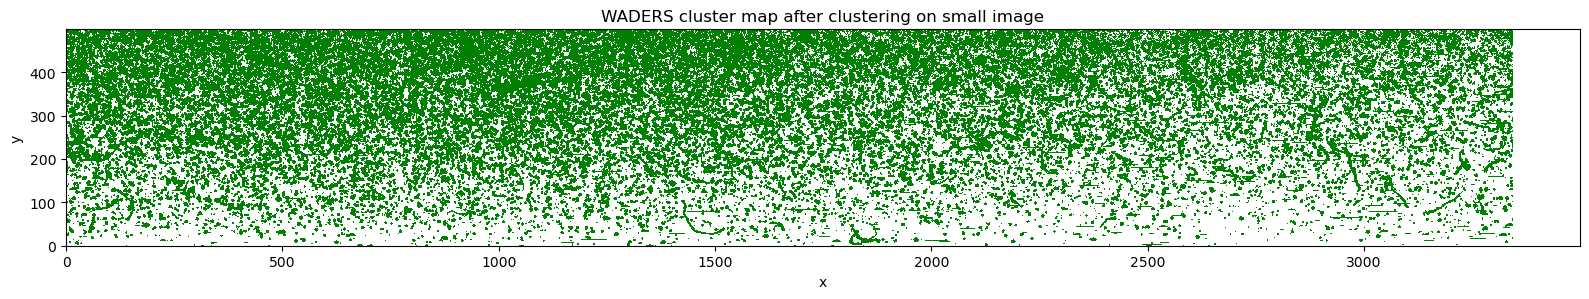

In [72]:
H, W = cal_img.shape
img = np.zeros((H, W), dtype=int)

for _, row in df_expanded.iterrows():
    xs = np.asarray(row["pixels_x"], dtype=int) - 1
    ys = np.asarray(row["pixels_y"], dtype=int) - 1
    img[ys, xs] = 1   # mark cluster pixels

# custom colormap: 0 -> white, 1 -> green
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["white", "green"])

plt.figure(figsize=(16, 10))
plt.imshow(img, origin="lower", cmap=cmap, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")
plt.title("WADERS cluster map after clustering on small image")
plt.tight_layout()
plt.show()


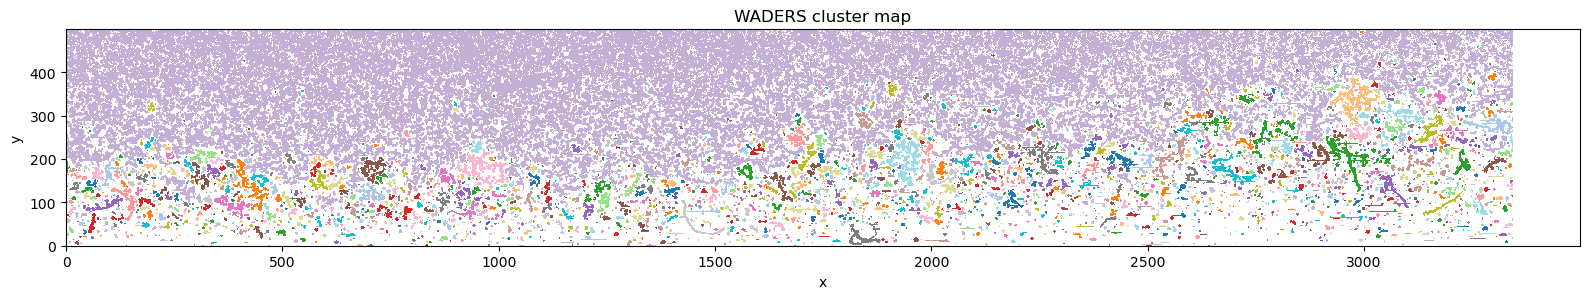

In [73]:
from matplotlib.colors import ListedColormap

H, W = cal_img.shape
img = np.zeros((H, W), dtype=int)

# assign a unique label to each cluster (starting from 1)
for label, (_, row) in enumerate(df_expanded.iterrows(), start=1):
    xs = np.asarray(row["pixels_x"], dtype=int) - 1
    ys = np.asarray(row["pixels_y"], dtype=int) - 1
    img[ys, xs] = label

# build a colormap: 0 = white, clusters = tab20 colors
n_clusters = len(df_expanded)
colors = ["white"] + list(plt.cm.tab20.colors) * ((n_clusters // 20) + 1)
cmap = ListedColormap(colors[: n_clusters + 1])

plt.figure(figsize=(16, 10))
plt.imshow(img, origin="lower", cmap=cmap, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")
plt.title("WADERS cluster map")
plt.tight_layout()
plt.show()


In [56]:
len(df_expanded)

3390

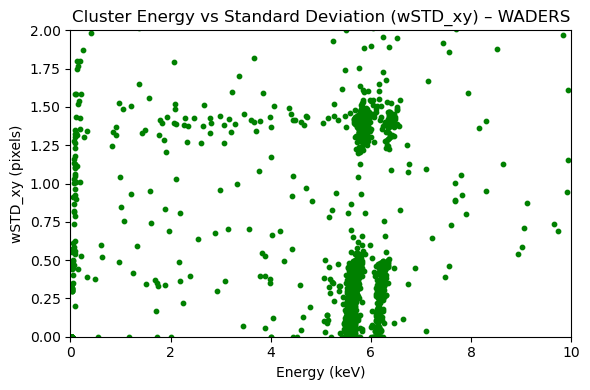

In [57]:
plt.figure(figsize=(6, 4))
plt.scatter(df_expanded["Energy"], df_expanded["wSTD_XY"], s=10, c="green")
plt.xlabel("Energy (keV)")
plt.ylabel("wSTD_xy (pixels)")
plt.title("Cluster Energy vs Standard Deviation (wSTD_xy) – WADERS")
plt.xlim(0,10)
plt.ylim(0,2)
plt.tight_layout()
plt.show()

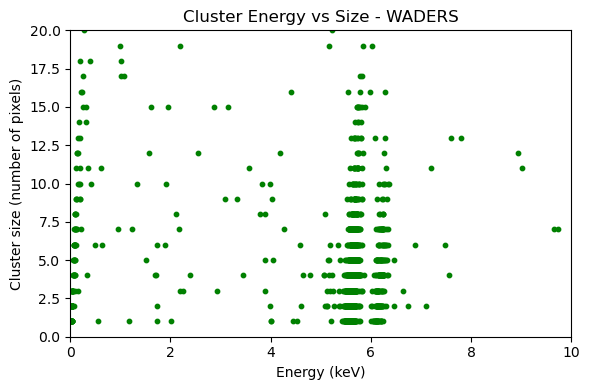

In [58]:
plt.figure(figsize=(6, 4))
plt.scatter(df_expanded["Energy"], df_expanded["Npix"], s=10, c="green")
plt.xlabel("Energy (keV)")
plt.ylabel("Cluster size (number of pixels)")
plt.title("Cluster Energy vs Size - WADERS")
plt.xlim(0,10)
plt.ylim(0,20)
plt.tight_layout()
plt.show()

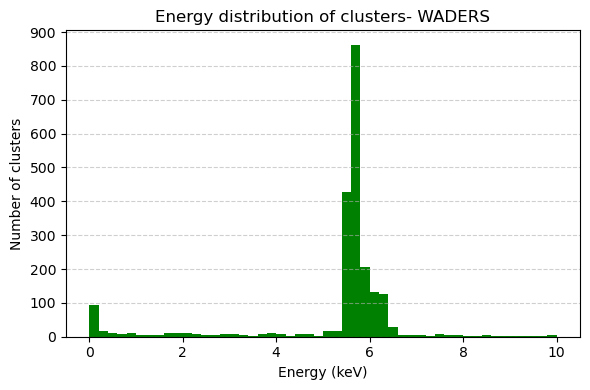

In [59]:
plt.figure(figsize=(6, 4))
plt.hist(df_expanded["Energy"], bins=50, color="green", range=(0, 10))
# range=(0, 10)
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters- WADERS")

# --- integer y-axis ticks ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 100))

# --- light grid aligned with ticks ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# # --- settings ---
# bins = 50
# hist_range = (2, 10)
# fit_min, fit_max = 5.0, 7.0   # fit 2 Gaussians only in this window

# # --- extract energy ---
# data = df_expanded["Energy"].to_numpy(dtype=float)
# data = data[np.isfinite(data)]

# # --- data used ONLY for mixture fit ---
# fit_data = data[(data >= fit_min) & (data <= fit_max)]

# # --- Fit 2-Gaussian mixture to UNBINNED data in 5–7 keV ---
# gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=0)
# gmm.fit(fit_data.reshape(-1, 1))

# means = gmm.means_.ravel()
# stds = np.sqrt(gmm.covariances_.ravel())
# weights = gmm.weights_.ravel()

# # sort by mean for nicer reporting/plotting
# order = np.argsort(means)
# means, stds, weights = means[order], stds[order], weights[order]

# # --- plot histogram ---
# plt.figure(figsize=(6, 4))
# counts, bin_edges, _ = plt.hist(
#     data, bins=bins, color="green", range=hist_range
# )

# plt.xlabel("Energy (keV)")
# plt.ylabel("Number of clusters")
# plt.title("Energy distribution of clusters – WADERS")

# # --- overlay 2-Gaussian mixture ONLY over 5–7 keV ---
# bin_width = bin_edges[1] - bin_edges[0]
# x = np.linspace(fit_min, fit_max, 800)

# pdf_components = [
#     weights[k] * norm.pdf(x, loc=means[k], scale=stds[k])
#     for k in range(2)
# ]
# pdf_total = np.sum(pdf_components, axis=0)

# scale = len(fit_data) * bin_width
# y_total = pdf_total * scale
# y_comps = [pc * scale for pc in pdf_components]

# plt.plot(x, y_total, linewidth=2)
# plt.plot(x, y_comps[0], linestyle="--", linewidth=1.8)
# plt.plot(x, y_comps[1], linestyle="--", linewidth=1.8)

# # --- annotate fit ---
# plt.text(
#     0.98, 0.98,
#     "2-Gaussian fit (5–7 keV)\n"
#     f"Comp 1: w={weights[0]:.2f}, μ={means[0]:.3f}, σ={stds[0]:.3f}\n"
#     f"Comp 2: w={weights[1]:.2f}, μ={means[1]:.3f}, σ={stds[1]:.3f}",
#     transform=plt.gca().transAxes,
#     ha="right", va="top",
#     bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
# )

# # --- y-axis ticks in chunks of 50 ---
# ax = plt.gca()
# ymax = int(ax.get_ylim()[1])
# ax.set_yticks(np.arange(0, ymax + 1, 50))

# # --- grid aligned with those ticks ---
# ax.grid(True, axis="y", linestyle="--", alpha=0.6)

# plt.tight_layout()
# plt.show()

# print("2-Gaussian mixture fit (5–7 keV):")
# print(f"  Comp 1: weight={weights[0]:.6f}, mean={means[0]:.6f}, std={stds[0]:.6f}")
# print(f"  Comp 2: weight={weights[1]:.6f}, mean={means[1]:.6f}, std={stds[1]:.6f}")

In [61]:
H, W = cal_img.shape

# --- GMM mask from df_blobs["points"] which stores [y,x,E] arrays ---
gmm_mask = np.zeros((H, W), dtype=bool)
for pts in df_blobs["points"]:
    pts = np.asarray(pts)
    ys = pts[:, 0].astype(int)
    xs = pts[:, 1].astype(int)
    gmm_mask[ys, xs] = True

# --- WADERS mask from df_expanded pixels_x/pixels_y (1-based -> convert to 0-based) ---
waders_mask = np.zeros((H, W), dtype=bool)
for _, row in df_expanded.iterrows():
    xs = np.asarray(row["pixels_x"], dtype=int) - 1
    ys = np.asarray(row["pixels_y"], dtype=int) - 1
    waders_mask[ys, xs] = True

overlap_mask = gmm_mask & waders_mask

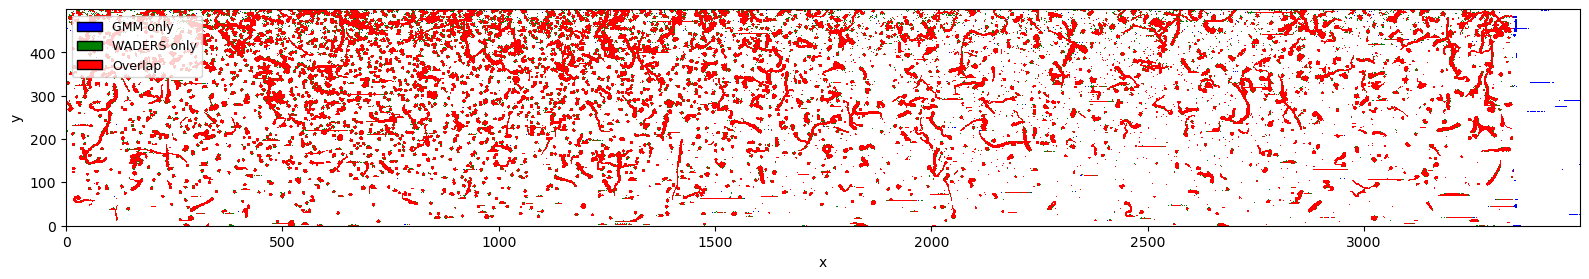

In [62]:
from matplotlib.patches import Patch

overlay = np.zeros((H, W), dtype=int)
overlay[gmm_mask & ~waders_mask] = 1
overlay[waders_mask & ~gmm_mask] = 2
overlay[overlap_mask] = 3

cmap_overlay = ListedColormap(["white", "blue", "green", "red"])

plt.figure(figsize=(16, 10))
plt.imshow(overlay, origin="lower", cmap=cmap_overlay, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")

# --- legend ---
legend_elements = [
    Patch(facecolor="blue",  edgecolor="black", label="GMM only"),
    Patch(facecolor="green", edgecolor="black", label="WADERS only"),
    Patch(facecolor="red",   edgecolor="black", label="Overlap"),
]

plt.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True,
    fontsize=9
)

plt.tight_layout()
plt.show()


WADERs in window: 1495
GMM in window:    1735
Matched: 1489
WADERs-only: 6
GMM-only:    246


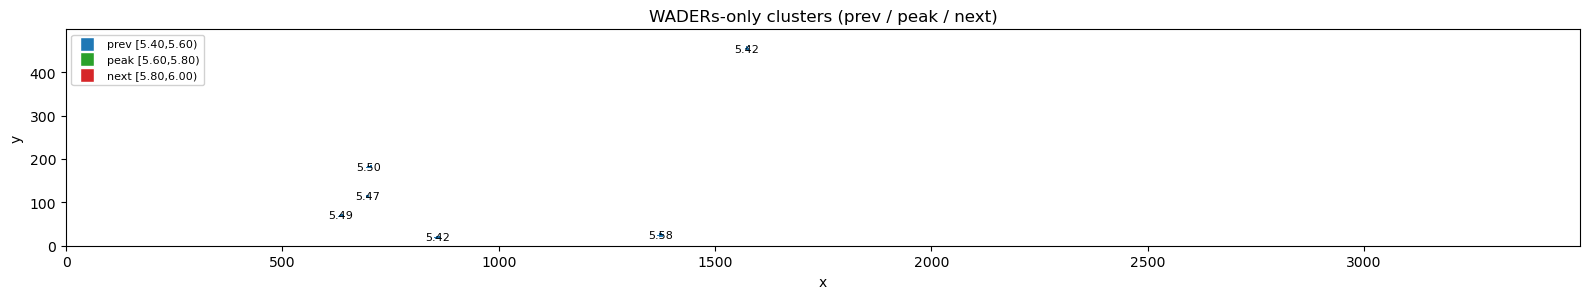

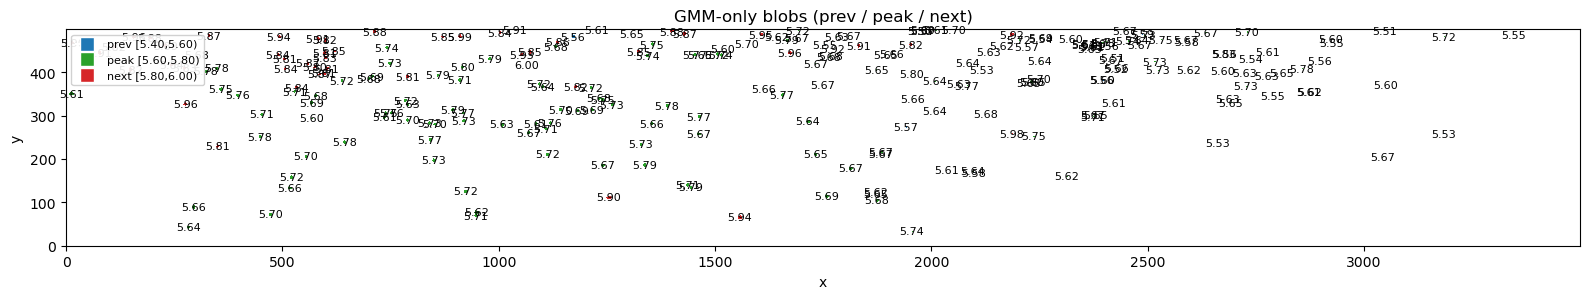

In [63]:
# -------------------------------
# 0) manual bins (same as you use)
# -------------------------------
peak_lo, peak_hi = 5.6, 5.8
bin_width = peak_hi - peak_lo
prev_lo, prev_hi = peak_lo - bin_width, peak_lo
next_lo, next_hi = peak_hi, peak_hi + bin_width
Emin, Emax = prev_lo, next_hi

def class_from_energy(E):
    if prev_lo <= E < prev_hi: return 0
    if peak_lo <= E < peak_hi: return 1
    if next_lo <= E < next_hi: return 2
    return None

# -------------------------------
# 1) extract clusters (pixels + centroid) for both methods
# -------------------------------
def extract_waders(df_expanded):
    out = []
    dfW = df_expanded[df_expanded["Energy"].between(Emin, Emax, inclusive="left")]
    for idx, row in dfW.iterrows():
        E = float(row["Energy"])
        c = class_from_energy(E)
        if c is None:
            continue
        xs = np.asarray(row["pixels_x"], dtype=int)
        ys = np.asarray(row["pixels_y"], dtype=int)
        if xs.size == 0:
            continue
        out.append({
            "id": idx,
            "E": E,
            "c": c,
            "xs": xs,
            "ys": ys,
            "cx": xs.mean(),
            "cy": ys.mean()
        })
    return out

def extract_gmm(df_blobs):
    out = []
    dfG = df_blobs[df_blobs["energy"].between(Emin, Emax, inclusive="left")]
    for idx, row in dfG.iterrows():
        E = float(row["energy"])
        c = class_from_energy(E)
        if c is None:
            continue
        pts = np.asarray(row["points"], dtype=float)  # [y, x, Epix]
        ys = pts[:, 0].astype(int)
        xs = pts[:, 1].astype(int)
        if xs.size == 0:
            continue
        out.append({
            "id": idx,
            "E": E,
            "c": c,
            "xs": xs,
            "ys": ys,
            "cx": xs.mean(),
            "cy": ys.mean()
        })
    return out

W_clusters = extract_waders(df_expanded)
G_clusters = extract_gmm(df_blobs)

print("WADERs in window:", len(W_clusters))
print("GMM in window:   ", len(G_clusters))

# -------------------------------
# 2) 1-to-1 matching by centroid distance
# -------------------------------
tol_px = 6.0      # tune if needed (try 6-10)
dE = None         # set to e.g. 0.05 if you want energy gating

cands = []  # (dist, wi, gi)
for wi, w in enumerate(W_clusters):
    for gi, g in enumerate(G_clusters):
        if dE is not None and abs(w["E"] - g["E"]) > dE:
            continue
        dist = np.hypot(w["cx"] - g["cx"], w["cy"] - g["cy"])
        if dist <= tol_px:
            cands.append((dist, wi, gi))

cands.sort(key=lambda t: t[0])

W_used = set()
G_used = set()
W_to_G = {}  # wi -> gi

for dist, wi, gi in cands:
    if wi in W_used or gi in G_used:
        continue
    W_used.add(wi)
    G_used.add(gi)
    W_to_G[wi] = gi

W_only = [W_clusters[i] for i in range(len(W_clusters)) if i not in W_used]
G_only = [G_clusters[i] for i in range(len(G_clusters)) if i not in G_used]

print("Matched:", len(W_to_G))
print("WADERs-only:", len(W_only))
print("GMM-only:   ", len(G_only))

# -------------------------------
# 3) make "only" label images
# -------------------------------
H, W = cal_img.shape

def make_rgb_from_only(clusters_only, title):
    cls = np.full((H, W), -1, dtype=np.int8)
    centroids = []

    for obj in clusters_only:
        xs = obj["xs"].astype(int)
        ys = obj["ys"].astype(int)

        m = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
        xs, ys = xs[m], ys[m]
        if xs.size == 0:
            continue

        cls[ys, xs] = obj["c"]
        centroids.append((xs.mean(), ys.mean(), obj["E"]))

    rgb = np.ones((H, W, 3), dtype=float)
    rgb[cls == 0] = (0.12, 0.47, 0.71)  # prev
    rgb[cls == 1] = (0.17, 0.63, 0.17)  # peak
    rgb[cls == 2] = (0.84, 0.15, 0.16)  # next

    plt.figure(figsize=(16, 10))
    plt.imshow(rgb, origin="lower", interpolation="none")

    for cx, cy, E in centroids:
        plt.text(cx, cy, f"{E:.2f}", ha="center", va="center", fontsize=8, color="black")

    plt.title(title)
    plt.xlabel("x"); plt.ylabel("y")

    plt.legend(
        handles=[
            plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=(0.12,0.47,0.71), markersize=10,
                       label=f"prev [{prev_lo:.2f},{prev_hi:.2f})"),
            plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=(0.17,0.63,0.17), markersize=10,
                       label=f"peak [{peak_lo:.2f},{peak_hi:.2f})"),
            plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=(0.84,0.15,0.16), markersize=10,
                       label=f"next [{next_lo:.2f},{next_hi:.2f})"),
        ],
        loc="upper left",
        fontsize=8,
        framealpha=0.9
    )

    plt.tight_layout()
    plt.show()

# -------------------------------
# 4) plot symmetric difference views
# -------------------------------
make_rgb_from_only(W_only, "WADERs-only clusters (prev / peak / next)")
make_rgb_from_only(G_only, "GMM-only blobs (prev / peak / next)")

In [64]:
cal_img.shape

(500, 3500)